# 06 — Management optimization: protecting the GDE under uncertainty

We reinject the contaminated water produced by pit dewatering through the MAR wells.
Reinjection raises heads near the GDE (supporting its **discharge**) but also carries
acidity toward it (threatening its **pH**). Here we find the cheapest mining scheme
(dewatering + MAR rates as decision variables), make it robust to parameter uncertainty,
discover that the discharge and pH protections conflict — and then resolve that conflict by
**treating** the reinjected water.

**Four scenarios, built up one requirement at a time:**
1. **base** — keep the pit dry and maintain GDE discharge near pre-development, at the posterior
   *base* (deterministic / risk-neutral). *No pH limit.*
2. **chance** — the same requirements, now enforced with **95% reliability** against the IES
   posterior stack (risk-averse): robustness to parameter uncertainty, at the cost of a more
   conservative scheme.
3. **chance_ph** — add **minimum GDE pH ≥ 6.0 at all times** on top. This comes out
   **infeasible**: maintaining GDE discharge means reinjecting near the GDE, which pushes acidic
   water toward it, so discharge and pH cannot both be met with untreated water.
4. **chance_ph_treat** — keep every requirement from `chance_ph`, but let the MAR water be
   **treated** (buffered and neutralised) before reinjection, with the **treatment fraction** as an
   extra decision variable. That lever lets the optimiser hold the pH line *and* the discharge: the
   problem becomes **feasible** again. Treatment is not free — the next notebook weighs its cost
   against the pumping it saves.

In [1]:
import os
import shutil
import re
import numpy as np
import pandas as pd
import flopy
import pyemu
import matplotlib.pyplot as plt

## Set up — template, decision variables, objective

In [2]:
t_d   = 'pst_template_opt'
ies_d = 'master_ies'          # IES posterior: optimisation template + chance-constraint stacks
if not os.path.exists(ies_d):
    raise Exception('run the history-matching notebook (05) first')
if os.path.exists(t_d):
    shutil.rmtree(t_d)
shutil.copytree(ies_d, t_d)

pst = pyemu.Pst(os.path.join(t_d, 'pest.pst'))
pe  = pst.ies.get('paren', pst.ies.phiactual.iteration.max())   # posterior parameter ensemble
par = pst.parameter_data
obs = pst.observation_data
par.loc[pe.columns, 'parval1'] = pe.loc['base', :].values.flatten()   # start from the posterior 'base'

# Decision variables: mining-period dewatering (extraction) and MAR (reinjection) rates
mine_grps = ['dewatwelgr', 'marwelgr']
par.loc[par.pargp == 'dewatwelgr', 'parlbnd'] = -3000.0
par.loc[par.pargp == 'dewatwelgr', 'parubnd'] = 0.0
par.loc[par.pargp == 'marwelgr',   'parlbnd'] = 0.0
par.loc[par.pargp == 'marwelgr',   'parubnd'] = 3000.0
par.loc[par.pargp.isin(mine_grps), 'partrans'] = 'none'
pst.pestpp_options['opt_dec_var_groups'] = mine_grps

# Objective: maximise the dewatering well flux at end of mining (= least extraction)
objname = obs.loc[(obs.oname == 'inc') & (obs.usecol == 'wel') & (obs.totim == '3651'), 'obsnme'].values[0]
pst.pestpp_options['opt_obj_func']  = objname
pst.pestpp_options['opt_direction'] = 'max'
print('decision groups :', mine_grps)
print('objective       :', objname, '(maximise)')

pest.3.par.
decision groups : ['dewatwelgr', 'marwelgr']
objective       : oname:inc_otype:lst_usecol:wel_totim:3651 (maximise)


## Reference run — base simulated values

Run the model once at the posterior base to get the pre-development GDE discharge (the flux constraint RHS).

In [3]:
pst.control_data.noptmax = 0
pst.write(os.path.join(t_d, 'pest.pst'), version=2)
pyemu.os_utils.run('pestpp-ies pest.pst', cwd=t_d)
pst.set_res(os.path.join(t_d, 'pest.base.rei'))

predev_flux = float(obs.loc['oname:drn_otype:lst_usecol:drn-gde_time:1', 'obsval'])
print(f'pre-development GDE discharge (flux constraint RHS): {predev_flux:,.0f} m3/d')

noptmax:0, npar_adj:964, nnz_obs:602
./pestpp-ies pest.pst


             pestpp-ies: a GLM iterative ensemble smoother

                   by the PEST++ development team

...processing command line: ' ./pestpp-ies pest.pst'
...using serial run manager


version: 5.2.26
binary compiled on Apr  9 2026 at 08:09:49
using control file: "pest.pst"
in directory: "/Users/ruihugman/GitHub/imwa-workshop-2026/tutorial/pst_template_opt"
on host: "Ruis-MacBook-Pro.local"
on a(n) apple operating system
with release configuration
started at 06/25/26 23:54:33

processing control file pest.pst

Note: 'NOPTMAX' == 0, switching to forgiveness mode when checking inputs

noptmax = 0, resetting max_run_fail = 1
parameter warning: 1 parameters are at lower bound
checking model IO files...done
              starting serial run manager ...


  ---  initializing  ---  
...checking phi factors in file phi.csv

  ---  'noptmax'=0, running control file parameter values and quitting  ---  
...saving control file p

## Constraints, chance stack, and the optimiser

- **Common** (all scenarios): pit head < 80 m at end of mining; GDE discharge ≤ pre-development;
  net extraction ≤ 0; well heads ≤ land surface; auto-flow-reduce ≥ −1 (anti-cheat).
- **Chance** (scenarios 2–3): constraints met with 95% reliability against the IES posterior stack.
- **pH** (scenario 3 only): minimum GDE pH ≥ 6.0 at every output time — adding it on top makes the problem infeasible.

In [4]:
PH_TIMES  = [1, 3651, 6571, 9491, 12411, 15331, 18251]   # sout output times (days)
PH_THRESH = 6.0
PIT_OBS   = 'oname:hdspit_otype:lst_usecol:hds_pit_i:49_j:49_time:3651'


def set_constraints(cons):
    """Zero all obs weights, then activate the listed (name, sense, rhs) constraints on the live pst."""
    o = pst.observation_data
    o['weight'] = 0.0
    for nme, sense, rhs in cons:
        o.loc[nme, 'obgnme'] = sense
        o.loc[nme, 'obsval'] = rhs
        o.loc[nme, 'weight'] = 1.0


def apply_structural():
    """Well head <= land surface and auto-flow-reduce >= -1. Run AFTER set_constraints (it zeros weights)."""
    o = pst.observation_data
    hobs = o.loc[o.obsnme.str.contains('hdslay1_t2'), :].copy()
    hobs['i'] = hobs.i.astype(int)
    hobs['j'] = hobs.j.astype(int)
    top = np.loadtxt(os.path.join(t_d, 'gwf.dis_top.txt')).reshape(hobs.i.max() + 1, hobs.j.max() + 1)
    wpar = par.loc[par.parnme.str.contains('wel'), :].copy()
    wpar['i'] = wpar.idx1.astype(int)
    wpar['j'] = wpar.idx2.astype(int)
    for i, j in zip(wpar.i, wpar.j):
        ij = hobs.loc[(hobs.i == i) & (hobs.j == j), :]
        o.loc[ij.obsnme, 'weight'] = 1.0
        o.loc[ij.obsnme, 'obgnme'] = 'less_than'
        o.loc[ij.obsnme, 'obsval'] = top[i, j]
    wr = o.loc[o.obsnme.str.contains('wel-reduc'), :]
    o.loc[wr.obsnme, 'weight'] = 1.0
    o.loc[wr.obsnme, 'obgnme'] = 'greater_than'
    o.loc[wr.obsnme, 'obsval'] = -1.0


def common_cons():
    return [
        (PIT_OBS,                                          'less_than', 80.0),
        ('oname:drn_otype:lst_usecol:drn-gde_time:3651',   'less_than', predev_flux),
        ('oname:inc_otype:lst_usecol:totwel_totim:3651',   'less_than', 0.0),
    ]


def ph_cons(thr=PH_THRESH):
    return [(f'oname:gde-ph_otype:lst_usecol:ph_min_time:{t}', 'greater_than', thr) for t in PH_TIMES]


CHANCE_KEYS = ['opt_par_stack', 'opt_obs_stack', 'opt_recalc_chance_every']


def set_chance(on):
    """Turn the IES-posterior chance stack on (95% reliability) or off (risk-neutral)."""
    if on:
        it = int(pd.read_csv(os.path.join(ies_d, 'pest.phi.actual.csv'))['iteration'].max())
        for kind in ['par', 'obs']:
            shutil.copy2(os.path.join(ies_d, f'pest.{it}.{kind}.jcb'),
                         os.path.join(t_d,   f'pest.{it}.{kind}.jcb'))
        pst.pestpp_options['opt_par_stack'] = f'pest.{it}.par.jcb'
        pst.pestpp_options['opt_obs_stack'] = f'pest.{it}.obs.jcb'
        pst.pestpp_options['opt_recalc_chance_every'] = 9999
        pst.pestpp_options['opt_risk'] = 0.95
    else:
        for k in CHANCE_KEYS:
            pst.pestpp_options.pop(k, None)
        pst.pestpp_options['opt_risk'] = 0.5     # risk-neutral


def set_treatment(on):
    """Make MAR treatment a decision variable (on) or hold the injected water untreated (off).

    `treat` is fixed (untreated, 0) through history matching; here we either release it as a
    decision variable in its own group `treatgr`, or pin it back to untreated. The forward-run
    pre-processor `apply_mar_treatment` blends the injected chemistry between the untreated and
    treated end-members by this fraction."""
    tpar = par.loc[par.pargp == 'treatgr', 'parnme']
    grps = [g for g in pst.pestpp_options['opt_dec_var_groups'] if g != 'treatgr']
    if on:
        par.loc[tpar, 'partrans'] = 'none'
        par.loc[tpar, 'parlbnd']  = 0.0
        par.loc[tpar, 'parubnd']  = 1.0
        par.loc[tpar, 'parval1']  = 1.0       # start full treatment (check for feasibility)
        grps.append('treatgr')
    else:
        par.loc[tpar, 'partrans'] = 'fixed'
        par.loc[tpar, 'parval1']  = 0.0       # untreated
    pst.pestpp_options['opt_dec_var_groups'] = grps

def run_opt(m_d, num_workers=min(10, os.cpu_count() - 1), noptmax=1):
    pst.rectify_pgroups()
    for g in pst.pestpp_options['opt_dec_var_groups']:
        pst.parameter_groups.loc[g, 'inctyp'] = 'absolute'
        if g == 'treatgr':
            pst.parameter_groups.loc[g, 'derinc'] = 0.25      # treatment fraction, range [0, 1]
        else:
            pst.parameter_groups.loc[g, 'derinc'] = 500.0 if 'mar' in g else -1000.0
    # Timeouts: the relative "overdue" mechanism (factor x mean run time) is unreliable here.
    # A few fast-finishing runs pull the mean down to ~1 s, so the relative threshold collapses
    # and any run that genuinely computes is killed as "overdue" (e.g. duration 15 s vs mean
    # 1.3 s -> killed at ~10x mean). Use an ABSOLUTE cap instead: disable the relative
    # give-up/reschedule and abandon a run only after a fixed wall-clock time.
    pst.pestpp_options['overdue_giveup_fac'] = 1.0e10     # effectively disable relative give-up
    pst.pestpp_options['overdue_resched_fac'] = 1.0e10    # effectively disable relative reschedule
    pst.pestpp_options['overdue_giveup_minutes'] = 60     # absolute per-run ceiling (min); tune to your run time
    pst.control_data.noptmax = noptmax
    pst.write(os.path.join(t_d, 'pest.pst'), version=2)
    pyemu.os_utils.start_workers(t_d, 'pestpp-opt', 'pest.pst',
                                 num_workers=num_workers, worker_root='.', master_dir=m_d)


def feasibility(m_d):
    rec = open(os.path.join(m_d, 'pest.rec')).read()
    n = re.findall(r'number primary infeasible constraints:\s*(\d+)', rec)
    n = int(n[-1]) if n else 0
    return 'FEASIBLE' if n == 0 else f'INFEASIBLE ({n})'

## Run the three scenarios

Each writes its own `master_opt_<tag>` directory. After each solve we re-run the model once at
the **optimal** decision variables (`confirm_at_optimum`) so the directory holds the achieved
observations at the optimum — pestpp-opt's own final run lands in a worker dir, and the master
dir otherwise keeps the *base* run.

In [5]:
scenarios = [
     ('base',            False, False, False),   # common constraints, deterministic (risk-neutral)
     ('base_ph',         True,  False, False),   # + GDE pH >= 6 at all times -> infeasible? (pH vs discharge)
     ('chance',          False, True,  False),   # common constraints, stochastic (risk-averse)
     ('base_ph_treat',   True,  False, True),    # + GDE pH >= 6 at all times, but MAR treatment is fixed (untreated) 
     ('chance_ph_treat', True,  True,  True),    # + MAR treatment as a decision variable -> feasible again
]


def confirm_at_optimum(m_d):
    """Re-run the model once at the optimal decision variables so the master dir holds the
    achieved obs (gde_ph.csv, drn, pit) at the optimum rather than the response-matrix base run.
    Uses a CLEAN IES pst (valid obs groups, no opt config) — pestpp-ies rejects the optimisation
    pst's constraint groups ('greater_than'/'less_than'). The optimal rates live in pest.par."""
    cpst = pyemu.Pst(os.path.join(ies_d, 'pest.pst'))
    cpst.parrep(os.path.join(m_d, 'pest.par'))     # optimal dec vars (base values for the rest)
    cpst.control_data.noptmax = 0
    cpst.write(os.path.join(m_d, 'confirm.pst'), version=2)
    pyemu.os_utils.run('pestpp-ies confirm.pst', cwd=m_d)


master, feas = {}, {}
for tag, minph, chance, treat in scenarios:
    set_constraints(common_cons() + (ph_cons() if minph else []))
    apply_structural()
    set_chance(chance)
    set_treatment(treat)
    m_d = f'master_opt_{tag}'
    if minph:
        noptmax = 5
    else:
        noptmax = 1
    run_opt(m_d, noptmax=noptmax)
    feas[tag] = feasibility(m_d)     # capture before the confirmation run overwrites pest.rec
    confirm_at_optimum(m_d)
    master[tag] = m_d
    print(f'{tag:>15}: {feas[tag]}')

# store the master dirs and feasibility results for later use
master_df = pd.DataFrame.from_dict(master, orient='index', columns=['master_dir'])
master_df['feasibility'] = pd.Series(feas)
master_df.to_csv(os.path.join('.', 'master_opt.csv'))


noptmax:1, npar_adj:963, nnz_obs:60


2026-06-25 23:55:18,324 - MainProcess - INFO - Reserved port 4784 for process 84235




             pestpp-opt - a tool for chance-constrained linear programming

                             by the PEST++ development team

...processing command line: ' ./pestpp-opt pest.pst /h :4784'
...using panther run manager in master mode using port 4784


version: 5.2.26
binary compiled on Apr  9 2026 at 08:09:49
using control file: "pest.pst"
in directory: "/Users/ruihugman/GitHub/imwa-workshop-2026/tutorial/master_opt_base"
on host: "Ruis-MacBook-Pro.local"
on a(n) apple operating system
with release configuration
started at 06/25/26 23:55:19

processing control file pest.pst
parameter warning: 1 parameters are at lower bound


:~-._                                                 _.-~:
: :.~^o._        ________---------________        _.o^~.:.:
 : ::.`?88booo~~~.::::::::...::::::::::::..~~oood88P'.::.:
 :  ::: `?88P .:::....         ........:::::. ?88P' :::. :
  :  :::. `? .::.            . ...........:::. P' .:::. :
   :  :::   ... ..  ...       .. .::::......::.   :::. :
  

2026-06-26 00:01:54,202 - MainProcess - INFO - Reserved port 4074 for process 84235




             pestpp-opt - a tool for chance-constrained linear programming

                             by the PEST++ development team

...processing command line: ' ./pestpp-opt pest.pst /h :4074'
...using panther run manager in master mode using port 4074


version: 5.2.26
binary compiled on Apr  9 2026 at 08:09:49
using control file: "pest.pst"
in directory: "/Users/ruihugman/GitHub/imwa-workshop-2026/tutorial/master_opt_base_ph"
on host: "Ruis-MacBook-Pro.local"
on a(n) apple operating system
with release configuration
started at 06/26/26 00:01:55

processing control file pest.pst
parameter warning: 1 parameters are at lower bound


:~-._                                                 _.-~:
: :.~^o._        ________---------________        _.o^~.:.:
 : ::.`?88booo~~~.::::::::...::::::::::::..~~oood88P'.::.:
 :  ::: `?88P .:::....         ........:::::. ?88P' :::. :
  :  :::. `? .::.            . ...........:::. P' .:::. :
   :  :::   ... ..  ...       .. .::::......::.   :::. :

...



             pestpp-opt - a tool for chance-constrained linear programming

                             by the PEST++ development team

...processing command line: ' ./pestpp-opt pest.pst /h :4915'
...using panther run manager in master mode using port 4915


version: 5.2.26
binary compiled on Apr  9 2026 at 08:09:49
using control file: "pest.pst"
in directory: "/Users/ruihugman/GitHub/imwa-workshop-2026/tutorial/master_opt_chance"
on host: "Ruis-MacBook-Pro.local"
on a(n) apple operating system
with release configuration
started at 06/26/26 00:07:55

processing control file pest.pst
parameter warning: 1 parameters are at lower bound


:~-._                                                 _.-~:
: :.~^o._        ________---------________        _.o^~.:.:
 : ::.`?88booo~~~.::::::::...::::::::::::..~~oood88P'.::.:
 :  ::: `?88P .:::....         ........:::::. ?88P' :::. :
  :  :::. `? .::.            . ...........:::. P' .:::. :
   :  :::   ... ..  ...       .. .::::......::.   :::. :


2026-06-26 00:14:19,061 - MainProcess - INFO - Reserved port 4633 for process 84235




             pestpp-opt - a tool for chance-constrained linear programming

                             by the PEST++ development team

...processing command line: ' ./pestpp-opt pest.pst /h :4633'
...using panther run manager in master mode using port 4633


version: 5.2.26
binary compiled on Apr  9 2026 at 08:09:49
using control file: "pest.pst"
in directory: "/Users/ruihugman/GitHub/imwa-workshop-2026/tutorial/master_opt_base_ph_treat"
on host: "Ruis-MacBook-Pro.local"
on a(n) apple operating system
with release configuration
started at 06/26/26 00:14:20

processing control file pest.pst
parameter warning: 1 parameters are at upper bound


:~-._                                                 _.-~:
: :.~^o._        ________---------________        _.o^~.:.:
 : ::.`?88booo~~~.::::::::...::::::::::::..~~oood88P'.::.:
 :  ::: `?88P .:::....         ........:::::. ?88P' :::. :
  :  :::. `? .::.            . ...........:::. P' .:::. :
   :  :::   ... ..  ...       .. .::::......::.   

2026-06-26 00:39:30,164 - MainProcess - INFO - Reserved port 4836 for process 84235




             pestpp-opt - a tool for chance-constrained linear programming

                             by the PEST++ development team

...processing command line: ' ./pestpp-opt pest.pst /h :4836'
...using panther run manager in master mode using port 4836


version: 5.2.26
binary compiled on Apr  9 2026 at 08:09:49
using control file: "pest.pst"
in directory: "/Users/ruihugman/GitHub/imwa-workshop-2026/tutorial/master_opt_chance_ph_treat"
on host: "Ruis-MacBook-Pro.local"
on a(n) apple operating system
with release configuration
started at 06/26/26 00:39:31

processing control file pest.pst
parameter warning: 1 parameters are at upper bound


:~-._                                                 _.-~:
: :.~^o._        ________---------________        _.o^~.:.:
 : ::.`?88booo~~~.::::::::...::::::::::::..~~oood88P'.::.:
 :  ::: `?88P .:::....         ........:::::. ?88P' :::. :
  :  :::. `? .::.            . ...........:::. P' .:::. :
   :  :::   ... ..  ...       .. .::::......::. 

## Optimal schemes — well-rate maps

Red = injection (MAR), blue = extraction (dewatering); grey background = log$_{10}$ K.

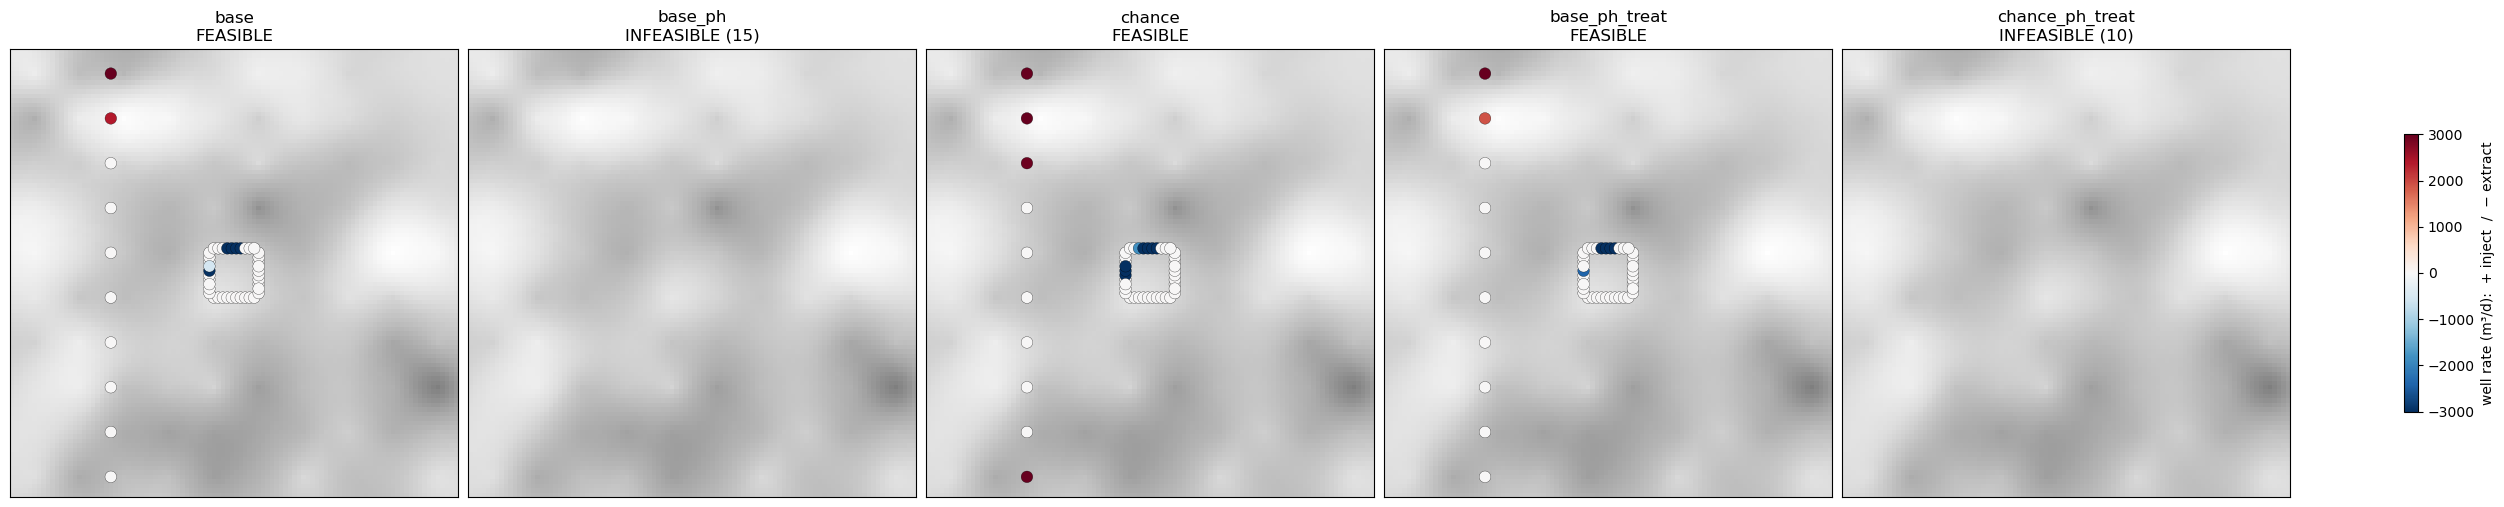

In [6]:
sim = flopy.mf6.MFSimulation.load(sim_ws=master['base'], verbosity_level=0)
gwf = sim.get_model()
mg  = gwf.modelgrid
X, Y = mg.xcellcenters, mg.ycellcenters

# log-K background from the hk observations in the pst
hkobs = obs.loc[obs.oname == 'hk', :].copy()
hkobs['i'] = hkobs.i.astype(int)
hkobs['j'] = hkobs.j.astype(int)
hkarr = np.full_like(X, np.nan, dtype=float)
hkarr[hkobs.i, hkobs.j] = np.log10(hkobs.obsval)

wpar = par.loc[par.parnme.str.contains('wel'), :].copy()
wpar['i'] = wpar.idx1.astype(int)
wpar['j'] = wpar.idx2.astype(int)
wpar['x'] = X[wpar.i, wpar.j]
wpar['y'] = Y[wpar.i, wpar.j]

fig, axes = plt.subplots(1, len(scenarios), figsize=(5 * len(scenarios), 5), constrained_layout=True)
for ax, (tag, *_) in zip(axes, scenarios):
    rates = pyemu.pst_utils.read_parfile(os.path.join(master[tag], 'pest.par'))
    ax.pcolormesh(X, Y, hkarr, cmap='Greys', alpha=0.5)
    pc = ax.scatter(wpar.x, wpar.y, c=rates.loc[wpar.parnme, 'parval1'].values,
                    s=70, cmap='RdBu_r', vmin=-3000, vmax=3000, edgecolor='k', linewidth=0.2)
    ax.set_title(f'{tag}\n{feas[tag]}')
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])
fig.colorbar(pc, ax=axes, shrink=0.6, label='well rate (m³/d):  + inject  /  − extract')
plt.show()

## Metrics

Values are the **confirmed** model run at each optimum (`feasible_LP` is pestpp-opt's *linear*
verdict). Note the constrained pit cell can sit slightly above the 80 m target: the response
matrix over-predicts drawdown because the dewatering wells hit `AUTO_FLOW_REDUCE` at desaturating
cells, so the real model extracts less. Tighten the pit RHS or raise `noptmax` (more SLP iterations)
to close that gap.

An **infeasible** scenario (here `chance_ph`) has no optimal scheme, so pestpp-opt returns non-finite decision variables and its metrics are blank (NaN) — only the `feasible_LP = INFEASIBLE` verdict is meaningful.

In [7]:
def _at_time(df, col, t=3651.0):
    return float(df.iloc[(df['time'] - t).abs().argmin()][col])

rows = []
for tag, *_ in scenarios:
    m_d   = master[tag]
    rates = pyemu.pst_utils.read_parfile(os.path.join(m_d, 'pest.par'))
    dew   = rates.loc[par.loc[par.pargp == 'dewatwelgr', 'parnme'], 'parval1'].sum()
    mar   = rates.loc[par.loc[par.pargp == 'marwelgr',   'parnme'], 'parval1'].sum()
    tpar  = par.loc[par.pargp == 'treatgr', 'parnme']
    treat = float(rates.loc[tpar, 'parval1'].iloc[0]) if len(tpar) else np.nan
    if not (np.isfinite(dew) and np.isfinite(mar)):
        # infeasible LP: pestpp-opt writes non-finite decision variables, and the
        # confirmation run at those values is meaningless -- report the row as NaN.
        rows.append(dict(scenario=tag, feasible_LP=feas[tag], dewater_m3d=np.nan,
                         MAR_m3d=np.nan, treatment=np.nan, min_pH=np.nan, GDE_flux_3651=np.nan,
                         pit_4949_3651=np.nan))
        continue
    gph   = pd.read_csv(os.path.join(m_d, 'gde_ph.csv'))                 # time, ph_min
    drn   = pd.read_csv(os.path.join(m_d, 'gwf.obs.drn.csv'))           # time, DRN-GDE
    pit   = pd.read_csv(os.path.join(m_d, 'gwf.obs.head.pit.csv'))      # time, HDS_PIT_*
    pit_row = pit.iloc[(pit['time'] - 3651.0).abs().argmin()]
    rows.append(dict(
        scenario        = tag,
        feasible_LP     = feas[tag],
        dewater_m3d     = round(dew),
        MAR_m3d         = round(mar),
        treatment       = round(treat, 2),                                # MAR treatment fraction (0-1)
        min_pH          = round(gph['ph_min'].min(), 2),
        GDE_flux_3651   = round(_at_time(drn, 'DRN-GDE')),
        pit_4949_3651   = round(float(pit_row['HDS_PIT_I:49_J:49']), 1),   # constrained cell (target < 80)
    ))
pd.DataFrame(rows).set_index('scenario')

,feasible_LP,dewater_m3d,MAR_m3d,treatment,min_pH,GDE_flux_3651,pit_4949_3651
scenario,,,,,,,
base,FEASIBLE,-15548.0,5377.0,0.0,5.61,-3295.0,84.2
base_ph,INFEASIBLE (15),NaN,NaN,NaN,NaN,NaN,NaN
chance,FEASIBLE,-22835.0,11936.0,0.0,5.59,-3452.0,81.4
base_ph_treat,FEASIBLE,-14397.0,4904.0,1.0,6.13,-3380.0,84.6
chance_ph_treat,INFEASIBLE (10),NaN,NaN,NaN,NaN,NaN,NaN


## GDE pH through time

Dashed line is the 6.0 threshold. The **base** and **chance** schemes do not constrain pH, so both let it drop. **chance_ph** demands pH ≥ 6.0 everywhere, but that is infeasible alongside the discharge constraint — even its returned scheme cannot hold the line. **chance_ph_treat** adds the treatment lever: by neutralising the reinjected water it lifts the minimum pH back above the threshold while still meeting discharge — the conflict is resolved (at a treatment cost, taken up in the next notebook).

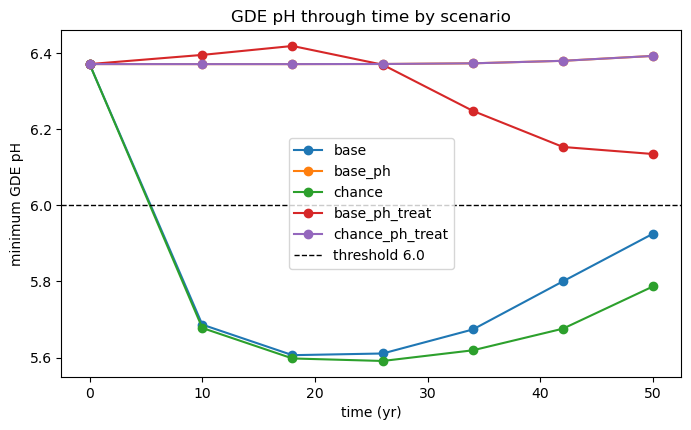

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for tag, *_ in scenarios:
    g = pd.read_csv(os.path.join(master[tag], 'gde_ph.csv'))
    ax.plot(g['time'] / 365.0, g['ph_min'], marker='o', label=tag)
ax.axhline(PH_THRESH, ls='--', color='k', lw=1, label=f'threshold {PH_THRESH}')
ax.set_xlabel('time (yr)')
ax.set_ylabel('minimum GDE pH')
ax.set_title('GDE pH through time by scenario')
ax.legend()
plt.show()